# `PiecewiseScheduler`

This notebook provides an empirical demonstration of the expected behavior of a `PiecewiseScheduler`. Its purpose is to make the module's scheduling behavior observable in a simple setting in which it can be studied in isolation, rather than to exhaustively validate every implementation detail.

The capability examined is piecewise scheduling across depth. A `PiecewiseScheduler` delegates different depth ranges to different schedulers, allowing the resulting schedule to combine multiple functional behaviors.

## Conceptual Overview

A `PiecewiseScheduler` defines a schedule from an ordered collection of segments, each consisting of a starting depth and an associated scheduler. For segment schedulers $S_0, S_1, \ldots, S_n$ beginning at depths $d_0 < d_1 < \cdots < d_n$, the value at depth $d$ is determined by the scheduler associated with the active segment:

$$
S(d)=S_i(d)
\qquad
\text{for } d_i \leq d < d_{i+1},
$$

with the final scheduler remaining active from $d_n$ onward.

Each segment therefore preserves the behavior of its underlying scheduler while the configured starting depths determine where the schedule transitions from one behavior to the next.

### Scope of the demonstration

The experiment evaluates a `PiecewiseScheduler` composed of power, polynomial, and exponential segments over a finite range of depths and visualizes the resulting schedule.

In [1]:
import matplotlib.pyplot as plt

from jacinta.utils.scheduler import (
    ExponentialScheduler,
    PiecewiseScheduler,
    PolynomialScheduler,
    PowerScheduler,
)

## Configuration

The parameters below are chosen to make the relevant behavior visible, but they should not be interpreted as general-purpose defaults.

`SEGMENTS` defines the ordered schedulers and the depths at which they become active.

At depth `0`, a `PowerScheduler` begins with a square-root relationship configured to increase from the origin.

At depth `2500`, a `PolynomialScheduler` takes over with a quadratic relationship that first increases and then decreases.

At depth `7500`, an `ExponentialScheduler` becomes active with a decreasing exponential relationship.

`MAX_DEPTH = 10000` determines the range over which the schedule is visualized. It does not affect the scheduler itself.

In [2]:
# hyperparameters
SEGMENTS = (
    (
        0,
        PowerScheduler(
            scale=10,
            exponent=0.5,
            offset=0,
            intercept=0,
            min_value=0,
            max_value=1000,
        ),
    ),
    (
        2500,
        PolynomialScheduler(
            coefficients=(125, 0.2, -0.00002),
            min_value=0,
            max_value=1000,
        ),
    ),
    (
        7500,
        ExponentialScheduler(
            scale=2241,
            rate=-0.0002,
            intercept=0,
            min_value=0,
            max_value=1000,
        ),
    ),
)

# plot parameters
MAX_DEPTH = 10000

## Visualization Utilities

The `PiecewiseScheduler` can be evaluated directly at a requested depth. The following helper exposes that mapping for visualization.

`plot_scheduler()` evaluates the scheduler at every depth from zero through `MAX_DEPTH` and plots the resulting schedule. This provides a direct view of its behavior across the displayed range.

In [3]:
def plot_scheduler(
    ax: plt.Axes,
    scheduler: PiecewiseScheduler,
) -> None:
    """
    Plot a scheduler.

    Args:
        ax (plt.Axes): The axes to plot on.
        scheduler (PiecewiseScheduler): The scheduler to plot.
    """
    # evaluate the scheduler
    depths = list(range(MAX_DEPTH + 1))
    values = [scheduler(depth) for depth in depths]
    # get the scheduler segments
    segments = " → ".join(
        f"{depth}: {type(segment).__name__}" for depth, segment in scheduler.segments
    )
    # plot the scheduler
    ax.plot(depths, values)
    ax.set_xlim(0, MAX_DEPTH)
    ax.set_xlabel("Depth")
    ax.set_ylabel("Value")
    ax.set_title(f"Piecewise Scheduler ({segments})")
    ax.grid(visible=True, alpha=0.3)
    return

## Evaluation

The plot shows three distinct behaviors across the displayed range. The power segment increases from `0` at depth `0` to `500` at depth `2500`. The polynomial segment then rises to `625` at depth `5000` before decreasing toward `500` as it approaches depth `7500`, where the exponential segment takes over at approximately `500.03` and decreases to approximately `303.29` at depth `10000`.

The resulting trajectory confirms that each configured depth range follows the behavior of its associated scheduler.

In [4]:
# initialize a PiecewiseScheduler
scheduler = PiecewiseScheduler(
    segments=SEGMENTS,
)

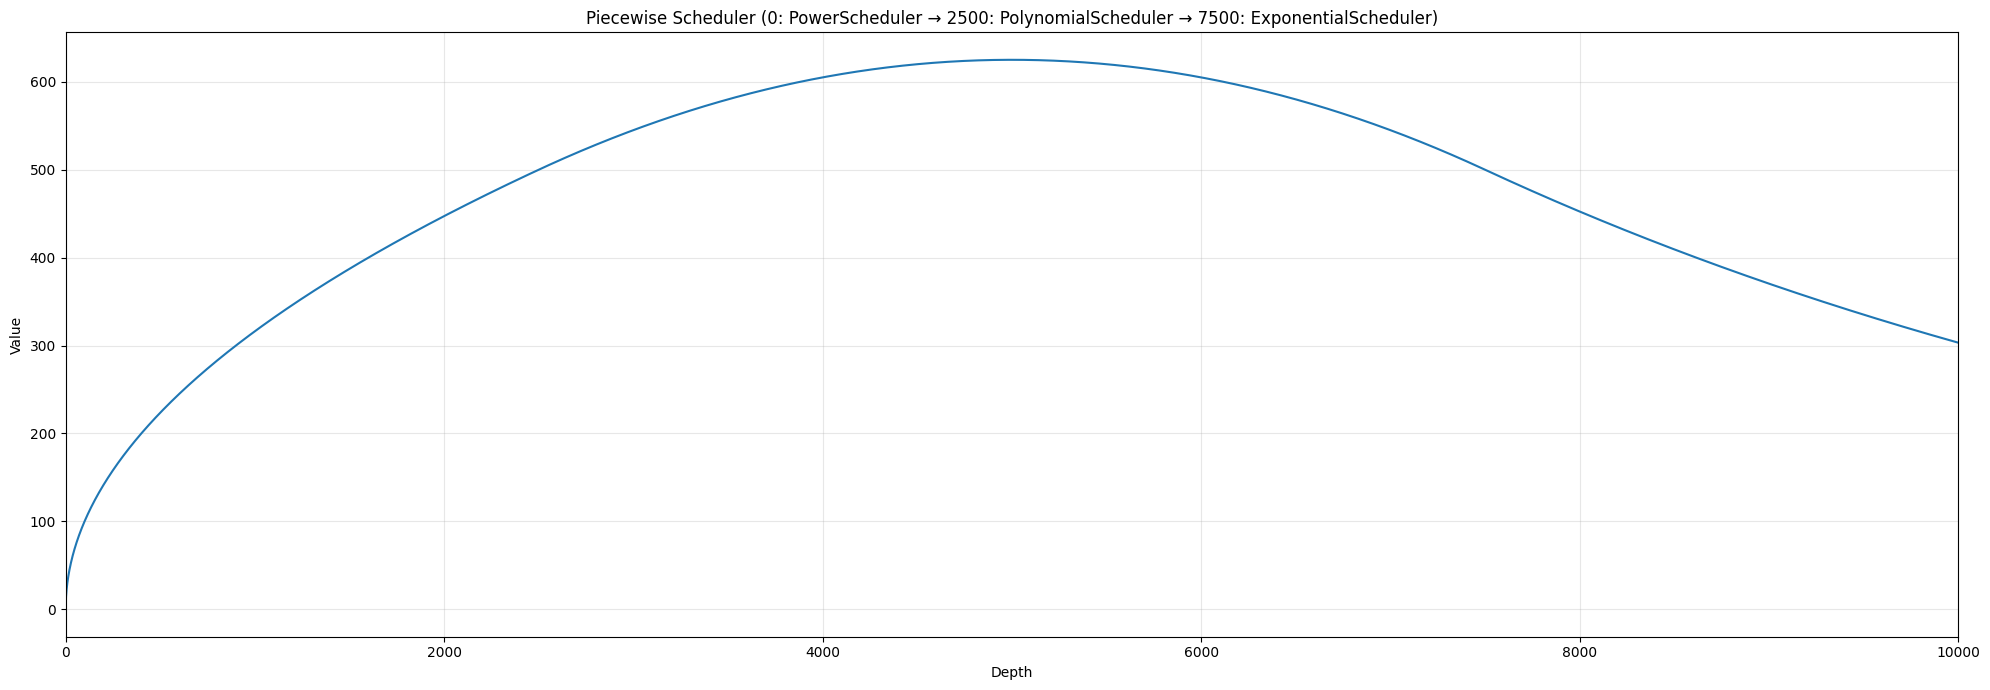

In [5]:
# plot the scheduler
fig, ax = plt.subplots(figsize=(20, 7))
plot_scheduler(ax, scheduler)
fig.tight_layout()
plt.show()

## Conclusions

This playground provides an empirical view of how a `PiecewiseScheduler` maps depth through a sequence of independently configured schedulers. Each segment contributes its own functional behavior, while the associated starting depths determine how those behaviors are combined across the complete schedule.

Examined in isolation, the module exhibits its intended behavior: it implements a piecewise scheduling strategy in which different schedulers govern different regions of depth.